# ⚖️ Confronto Prático: Watershed vs. K-Means em Objetos Sobrepostos
### Universidade Federal do Piauí – UFPI | Campus Senador Helvídio Nunes de Barros
**Disciplina:** Tópicos Especiais em Visão Computacional — Prof. José Denes Lima Araújo  
**Grupo 4:** Técnicas de Segmentação Baseada em Região (Seção 10.5 — Gonzalez & Woods)  
**Apresentador:** Integrante 3 — *O Analista Experimental (Slide 11: Discussão Comparativa das Particularidades)*  

---

## 📌 A Pergunta Provocativa da Banca
> *"Se o K-Means é um algoritmo de agrupamento tão popular e flexível, por que simplesmente não usamos K-Means para segmentar e contar as moedas ou células que estão se tocando?"*

Neste notebook, submetemos a **mesma imagem de moedas tangentes** a ambos os métodos para responder empiricamente e de forma definitiva a essa pergunta fundamental da engenharia de visão computacional!


In [1]:
# 1. Importação e Preparação
import os
import urllib.request
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

os.makedirs("imagens", exist_ok=True)
os.makedirs("resultados", exist_ok=True)

img_path = os.path.join("imagens", "moedas_sobrepostas.jpg")
if not os.path.exists(img_path):
    url = "https://raw.githubusercontent.com/opencv/opencv/4.x/doc/py_tutorials/py_imgproc/py_watershed/images/water_coins.jpg"
    urllib.request.urlretrieve(url, img_path)

img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)


## 2. Aplicação do K-Means na Imagem de Moedas
Como a imagem possui dois planos dominantes (moedas de bronze e fundo branco), aplicamos o K-Means com $K=2$ e também com $K=3$ para tentar isolar as moedas:


In [2]:
# Execução do K-Means nas moedas (K = 2 e K = 3)
pixels = img_rgb.reshape((-1, 3)).astype(np.float32)
criterio = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

_, labels_k2, centers_k2 = cv2.kmeans(pixels, 2, None, criterio, 10, cv2.KMEANS_RANDOM_CENTERS)
seg_k2 = np.uint8(centers_k2)[labels_k2.flatten()].reshape(img_rgb.shape)
mapa_k2 = labels_k2.reshape((img_rgb.shape[0], img_rgb.shape[1]))

# Identifica qual cluster corresponde às moedas (o de menor luminosidade média)
cluster_moeda = np.argmin(np.mean(centers_k2, axis=1))
mascara_moedas_kmeans = np.uint8(mapa_k2 == cluster_moeda)

# Verificação de componentes conexos após K-Means
num_comp_kmeans, _ = cv2.connectedComponents(mascara_moedas_kmeans)
print(f"🚨 K-MEANS EM OBJETOS TANGENTES:")
print(f"Componentes conexos encontrados a partir da máscara do K-Means: {num_comp_kmeans - 1}")
print("-> O K-Means falha na separação por toque: todas as moedas encostadas possuem a mesma cor, logo caem no mesmo cluster!")


🚨 K-MEANS EM OBJETOS TANGENTES:
Componentes conexos encontrados a partir da máscara do K-Means: 2
-> O K-Means falha na separação por toque: todas as moedas encostadas possuem a mesma cor, logo caem no mesmo cluster!


## 3. Aplicação do Watershed na Mesma Imagem
Agora executamos o pipeline de Watershed guiado pela Transformada de Distância Euclidiana:


In [3]:
# Pipeline do Watershed
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
sure_bg = cv2.dilate(opening, kernel, iterations=3)

dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

unknown = cv2.subtract(sure_bg, sure_fg)
num_labels_ws, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

img_ws_result = img_rgb.copy()
markers_result = cv2.watershed(img_ws_result, markers)
img_ws_result[markers_result == -1] = [255, 0, 0]

moedas_ws = len(np.unique(markers_result)) - 2  # Desconta fundo e borda
print(f"🎯 WATERSHED COM MARCADORES:")
print(f"Moedas individualizadas com sucesso: {moedas_ws}")


🎯 WATERSHED COM MARCADORES:
Moedas individualizadas com sucesso: 24


## 4. O Duelo Visual Lado a Lado (Figura do Slide 11)
Abaixo confrontamos diretamente o resultado do K-Means com o resultado do Watershed na mesma imagem:


Figura de duelo prático salva em: resultados\comparativo_toque_watershed_vs_kmeans.png


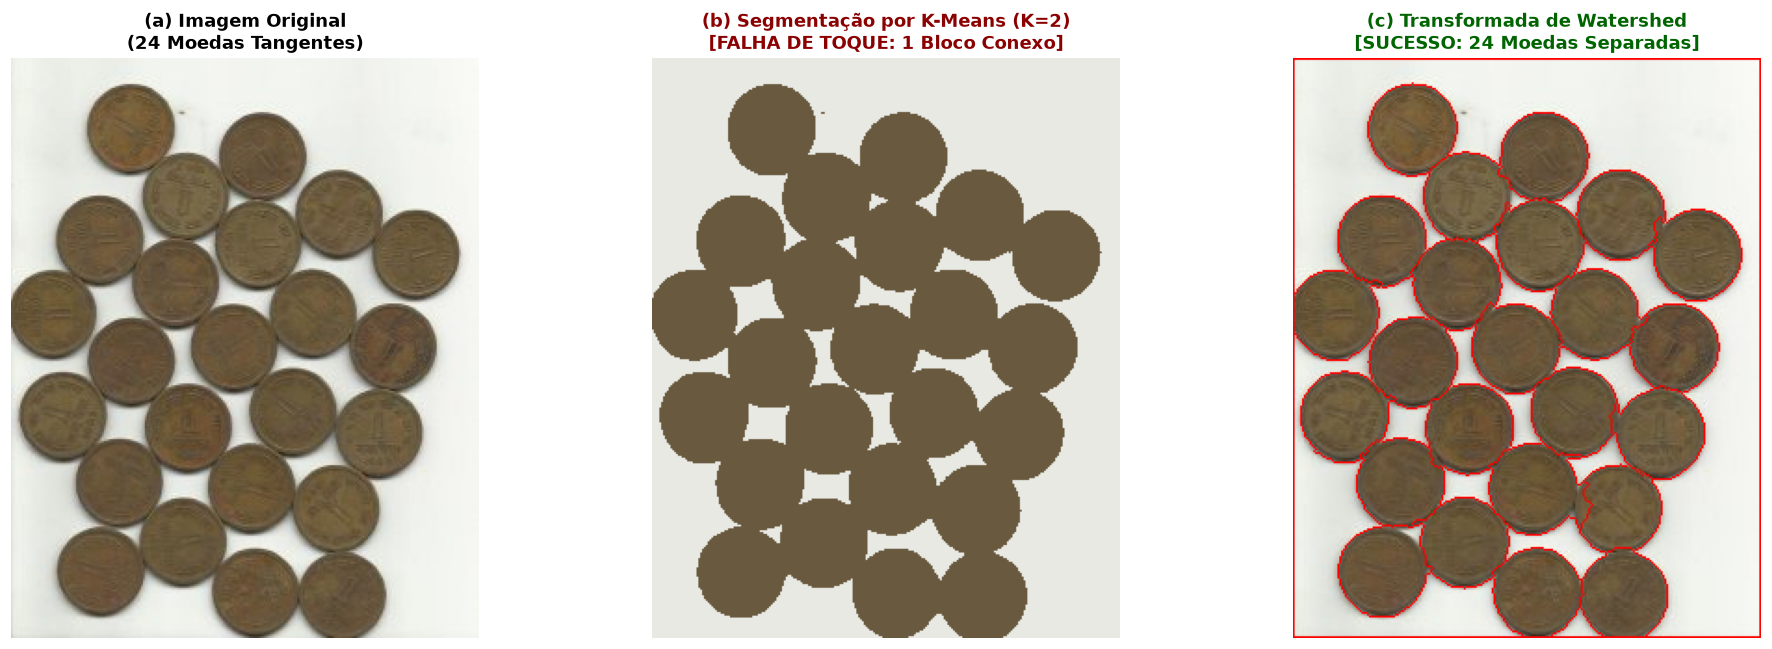

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_rgb)
axes[0].set_title("(a) Imagem Original\n(24 Moedas Tangentes)", fontsize=12, fontweight='bold')
axes[0].axis("off")

axes[1].imshow(seg_k2)
axes[1].set_title(f"(b) Segmentação por K-Means (K=2)\n[FALHA DE TOQUE: 1 Bloco Conexo]", fontsize=12, fontweight='bold', color='darkred')
axes[1].axis("off")

axes[2].imshow(img_ws_result)
axes[2].set_title(f"(c) Transformada de Watershed\n[SUCESSO: {moedas_ws} Moedas Separadas]", fontsize=12, fontweight='bold', color='darkgreen')
axes[2].axis("off")

plt.tight_layout()
output_duelo = os.path.join("resultados", "comparativo_toque_watershed_vs_kmeans.png")
plt.savefig(output_duelo, dpi=180, bbox_inches='tight')
print(f"Figura de duelo prático salva em: {output_duelo}")
plt.show()


## 5. Tabela Analítica das 3 Dimensões Fundamentais (Slide 11)

| Dimensão Técnica | Transformada de Watershed | Clustering K-Means | Vencedor Prático |
| :--- | :--- | :--- | :--- |
| **1. Separação de Toque** | Excelente. Utiliza a curvatura do relevo da distância topográfica para erguer barragens nos pontos de estrangulamento. | Nula. Objetos encostados da mesma cor possuem idêntica assinatura espectral, fundindo-se no mesmo cluster. | 🏆 **Watershed** |
| **2. Dependência de Bordas** | Elevada. Depende de gradientes nítidos ou formato geométrico definido para calcular distâncias. | Independente. Segmenta texturas e cores mesmo com contornos difusos ou sem bordas nítidas. | 🏆 **K-Means** |
| **3. Prontidão para Análise** | Imediata. Entrega regiões fechadas com rótulos únicos prontas para contagem, cálculo de área e perímetro. | Requer Pós-processamento. Entrega nuvens de pixels sem garantia de conexidade espacial. | 🏆 **Watershed** |

---

## 6. Recomendações Finais de Engenharia (Slide 12)
- **Quando usar Watershed com Marcadores:**
  - Aplicações de contagem automatizada e metrologia (células, colônias bacterianas, sementes, moedas, peças mecânicas).
  - Imagens onde objetos possuem limites geométricos reconhecíveis e tocam-se levemente.
- **Quando usar K-Means / Superpixels:**
  - Simplificação de cenas complexas, compressão cromática e quantização de cores.
  - Pré-processamento semântico para sistemas de alto nível e redes neurais profundas (CNNs).
